## Part A: ENO -- Notifiable Diseases (5 pts)

### A.0 Data Loading & Cleaning (1 pt)

#### A. 0.1 Load the ENO dataset

In [30]:
import pandas as pd

eno_cols = [
    "ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
    "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
    "cie_10_diagnostico", "diagnostico", "pais_contagio"
]

eno = pd.read_csv(
    "../Datos/20241218_base_eno_final.csv",
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols
)

print("Shape:", eno.shape)
eno.info()

Shape: (333300, 11)
<class 'pandas.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   region                    333300 non-null  str  
 1   nacionalidad              333300 non-null  str  
 2   cie_10_diagnostico        333300 non-null  str  
 3   diagnostico               333300 non-null  str  
 4   anho_notificacion         333300 non-null  int64
 5   ENO                       333300 non-null  str  
 6   nombre_instruccion        333300 non-null  str  
 7   pais_contagio             333300 non-null  str  
 8   sexo                      333300 non-null  str  
 9   grupo_edad                333300 non-null  str  
 10  codigo_comuna_residencia  333300 non-null  str  
dtypes: int64(1), str(10)
memory usage: 65.4 MB


Loads the ENO dataset, keeps the columns used in the analysis, and shows a quick overview of the table.


#### A. 0.2 Filter to your comunas

In [31]:
MY_COMUNAS = [13301, 13501, 13601]
my_comunas_str = [str(c) for c in MY_COMUNAS]

eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy()
print(f"Rows in my comunas: {len(eno_com):,}")

anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
print(f"Rows with anonymized comuna code (*****): {anon_count:,}")

Rows in my comunas: 2,397
Rows with anonymized comuna code (*****): 148,217


Filters the ENO records to Colina, Melipilla, and Talagante, and also counts rows with anonymized comuna codes.


#### A. 0.3 Clean the nationality variable


In [32]:
nat_dist = eno_com["nacionalidad"].value_counts(dropna=False)
nat_pct = eno_com["nacionalidad"].value_counts(normalize=True, dropna=False) * 100

nat_summary = pd.DataFrame({
    "count": nat_dist,
    "percentage": nat_pct.round(2)
})

nat_summary

,count,percentage
nacionalidad,,
Chile,1149,47.93
Desconocido,797,33.25
Extranjero,451,18.82


Summarizes the nationality variable with counts and percentages for the selected comunas.


In [33]:
unknown_nat = (eno_com["nacionalidad"] == "Desconocido").sum()

print(f"Rows with 'Desconocido' nationality: {unknown_nat:,}")

eno_com_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

print(f"Rows after excluding 'Desconocido': {len(eno_com_nat):,}")

dropped_pct = unknown_nat / len(eno_com) * 100

print(f"Percentage dropped: {dropped_pct:.2f}%")

Rows with 'Desconocido' nationality: 797
Rows after excluding 'Desconocido': 1,600
Percentage dropped: 33.25%


Counts the rows with unknown nationality and creates a clean version of the data without them.


#### A. 0.4 Report the time span


In [34]:
year_min = eno_com["anho_notificacion"].min()
year_max = eno_com["anho_notificacion"].max()

print(f"Time span in filtered ENO data: {year_min} to {year_max}")
notifications_per_year = (
    eno_com.groupby("anho_notificacion")
    .size()
    .reset_index(name="n_notifications")
    .sort_values("anho_notificacion")
    .reset_index(drop=True)
)

print(f"Total notifications in assigned comunas: {len(eno_com):,}")
print(f"Time span in filtered ENO data: {year_min} to {year_max}")
notifications_per_year

Time span in filtered ENO data: 2007 to 2024
Total notifications in assigned comunas: 2,397
Time span in filtered ENO data: 2007 to 2024


,anho_notificacion,n_notifications
0,2007,60
1,2008,31
2,2009,56
3,2010,38
4,2011,69
5,2012,79
6,2013,79
7,2014,95
8,2015,103
9,2016,90


Finds the time span of the ENO data and builds a table with the total notifications per year.


### A.1 Notification Trends Over Time (1 pt)


#### A. 1.1 Overall trend


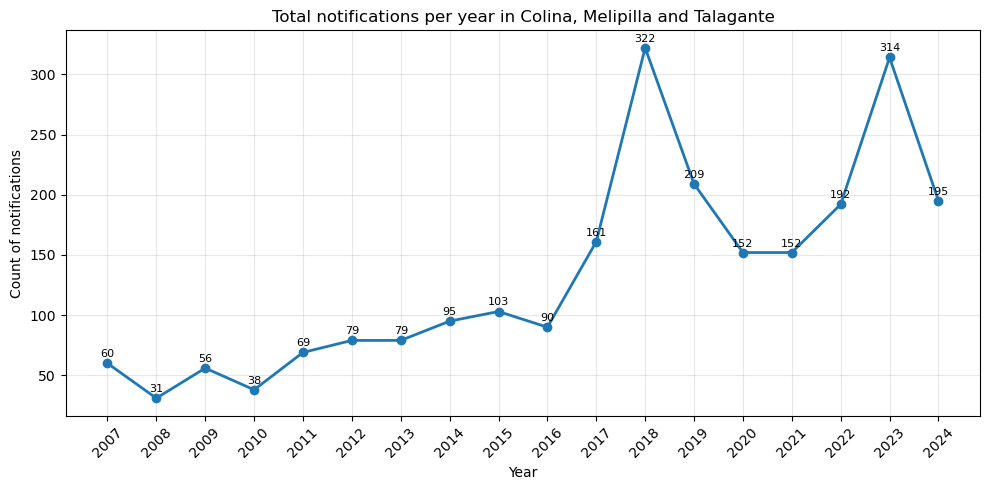

In [35]:
import matplotlib.pyplot as plt

notifications_per_year = (
    eno_com.groupby("anho_notificacion")
    .size()
    .reset_index(name="n_notifications")
    .sort_values("anho_notificacion")
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
plt.plot(
    notifications_per_year["anho_notificacion"],
    notifications_per_year["n_notifications"],
    marker="o",
    linewidth=2
)

for _, row in notifications_per_year.iterrows():
    plt.text(
        row["anho_notificacion"],
        row["n_notifications"] + 5,
        str(row["n_notifications"]),
        ha="center",
        fontsize=8
    )

plt.title("Total notifications per year in Colina, Melipilla and Talagante")
plt.xlabel("Year")
plt.ylabel("Count of notifications")
plt.xticks(notifications_per_year["anho_notificacion"], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Creates a line chart to show how total ENO notifications change over time.


Comentar sobre alguna caÃ­da o salto visible, como por ej efectos del periodo covid-19 en la vigilancia)

#### A. 1.2 Trend by nationality


Rows excluded because nacionalidad = 'Desconocido': 797
Rows kept for nationality analysis: 1,600


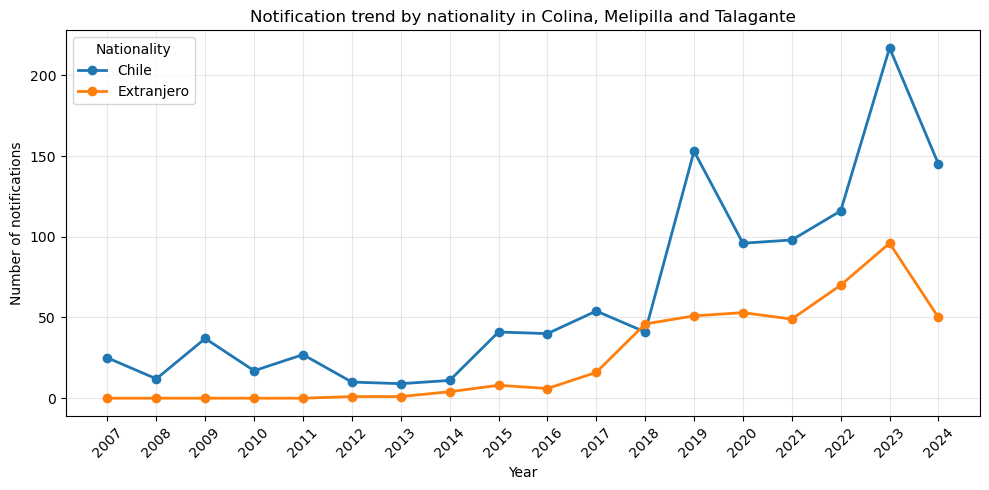

nacionalidad,anho_notificacion,Chile,Extranjero,total_notifications,foreign_share_pct
0,2007,25.0,0.0,25.0,0.00
1,2008,12.0,0.0,12.0,0.00
2,2009,37.0,0.0,37.0,0.00
3,2010,17.0,0.0,17.0,0.00
4,2011,27.0,0.0,27.0,0.00
5,2012,10.0,1.0,11.0,9.09
6,2013,9.0,1.0,10.0,10.00
7,2014,11.0,4.0,15.0,26.67
8,2015,41.0,8.0,49.0,16.33
9,2016,40.0,6.0,46.0,13.04


In [36]:
dropped_unknown = (eno_com["nacionalidad"] == "Desconocido").sum()
eno_com_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

print(f"Rows excluded because nacionalidad = 'Desconocido': {dropped_unknown:,}")
print(f"Rows kept for nationality analysis: {len(eno_com_nat):,}")

nat_year = (
    eno_com_nat.groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="n_notifications")
)

nat_year_wide = (
    nat_year.pivot(
        index="anho_notificacion",
        columns="nacionalidad",
        values="n_notifications"
    )
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(10, 5))

for nationality in nat_year_wide.columns:
    plt.plot(
        nat_year_wide.index,
        nat_year_wide[nationality],
        marker="o",
        linewidth=2,
        label=nationality
    )

plt.title("Notification trend by nationality in Colina, Melipilla and Talagante")
plt.xlabel("Year")
plt.ylabel("Number of notifications")
plt.xticks(nat_year_wide.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

nat_share = nat_year_wide.copy()
nat_share["total_notifications"] = nat_share.sum(axis=1)
nat_share["foreign_share_pct"] = (
    nat_share["Extranjero"] / nat_share["total_notifications"] * 100
).round(2)

nat_share = nat_share.reset_index()
nat_share[["anho_notificacion", "Chile", "Extranjero", "total_notifications", "foreign_share_pct"]]

Removes unknown nationality cases, compares yearly trends by nationality, and calculates the foreign share each year. Furthermore, we can see that Chile has been leading in the number of notifications every year, except for 2018, where, as can be seen, Chile was surpassed by foreigners.


### A.2 Disease Profiles (1.5 pts)


#### A. 2.1 Top diseases overall


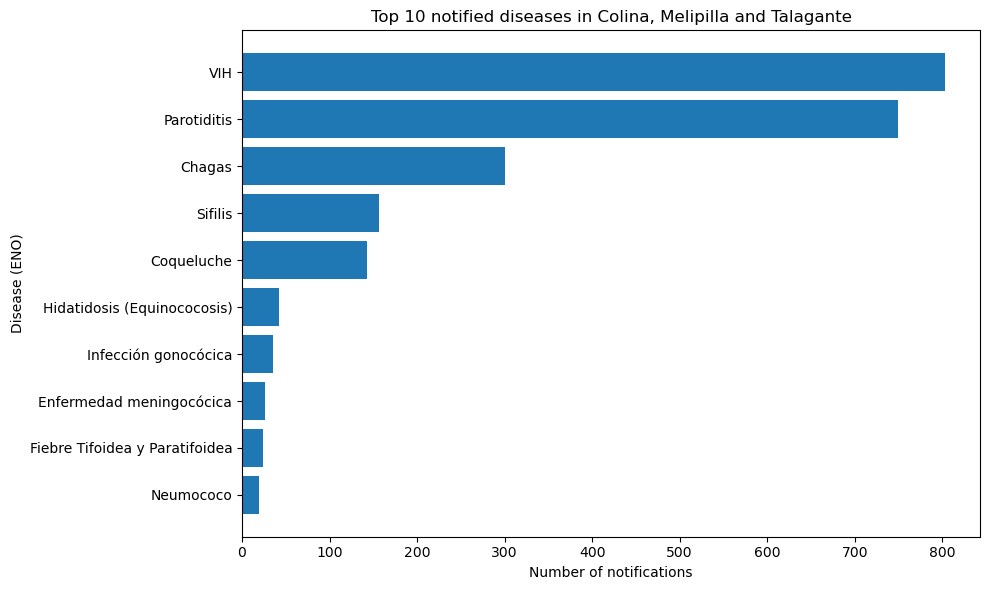

,ENO,n_notifications
24,VIH,803
19,Parotiditis,750
3,Chagas,301
21,Sifilis,156
4,Coqueluche,143
12,Hidatidosis (Equinococosis),42
13,InfecciÃ³n gonocÃ³cica,35
6,Enfermedad meningocÃ³cica,26
7,Fiebre Tifoidea y Paratifoidea,24
18,Neumococo,19


In [37]:
top10_diseases = (
    eno_com.groupby("ENO")
    .size()
    .reset_index(name="n_notifications")
    .sort_values("n_notifications", ascending=False)
    .head(10)
)

top10_plot = top10_diseases.sort_values("n_notifications", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top10_plot["ENO"], top10_plot["n_notifications"])

plt.title("Top 10 notified diseases in Colina, Melipilla and Talagante")
plt.xlabel("Number of notifications")
plt.ylabel("Disease (ENO)")
plt.tight_layout()
plt.show()

top10_diseases

Identifies the 10 most frequent diseases and plots them for an easy comparison. Furthermore, it can be seen that HIV, along with Mumps, leads by a considerable amount in the total number of notifications.


#### A. 2.2 Disease profiles by nationality


In [38]:
summary_table = pd.read_csv("../Datos/summary_table_part4.csv")

summary_selected = summary_table[
    summary_table["nombre_comuna"].isin(["Colina", "Melipilla", "Talagante"])
].copy()

pct_foreign = (
    summary_selected["pop_foreign"].sum() / summary_selected["pop_total"].sum()
) * 100

print(f"Combined pct_foreign for Colina, Melipilla and Talagante: {pct_foreign:.2f}%")

Combined pct_foreign for Colina, Melipilla and Talagante: 9.88%


Loads the summary table from Tarea 1 and calculates the combined foreign population share of the three comunas.


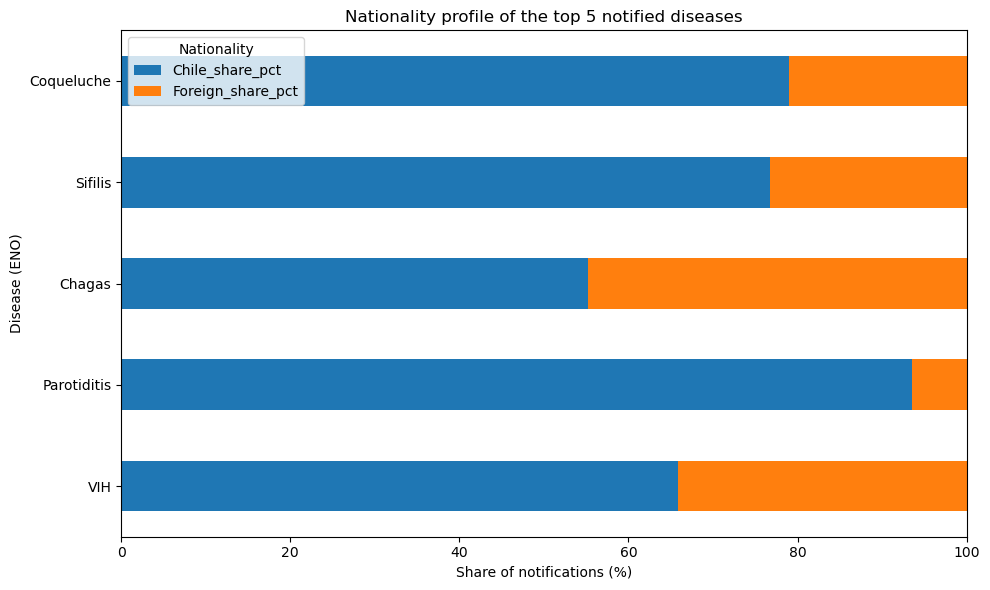

Rows excluded because nacionalidad = 'Desconocido': 797
Reference foreign population share from Tarea 1 (pct_foreign): 9.88%


nacionalidad,ENO,Chile,Extranjero,total_notifications,Chile_share_pct,Foreign_share_pct,Overrepresented_vs_local_population
0,VIH,460,238,698,65.90,34.10,True
1,Parotiditis,259,18,277,93.50,6.50,False
2,Chagas,164,133,297,55.22,44.78,True
3,Sifilis,119,36,155,76.77,23.23,True
4,Coqueluche,15,4,19,78.95,21.05,True


In [ ]:
eno_com_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

top5_diseases = (
    eno_com["ENO"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

disease_nat_profile = (
    eno_com_nat[eno_com_nat["ENO"].isin(top5_diseases)]
    .groupby(["ENO", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Chile", "Extranjero"]:
    if col not in disease_nat_profile.columns:
        disease_nat_profile[col] = 0

disease_nat_profile = disease_nat_profile.reindex(top5_diseases)

disease_nat_profile["total_notifications"] = (
    disease_nat_profile["Chile"] + disease_nat_profile["Extranjero"]
)

disease_nat_profile["Chile_share_pct"] = (
    disease_nat_profile["Chile"] / disease_nat_profile["total_notifications"] * 100
).round(2)

disease_nat_profile["Foreign_share_pct"] = (
    disease_nat_profile["Extranjero"] / disease_nat_profile["total_notifications"] * 100
).round(2)

try:
    reference_pct_foreign = pct_foreign
except NameError:
    reference_pct_foreign = None

if reference_pct_foreign is not None:
    disease_nat_profile["Overrepresented_vs_local_population"] = (
        disease_nat_profile["Foreign_share_pct"] > reference_pct_foreign
    )
else:
    disease_nat_profile["Overrepresented_vs_local_population"] = None

disease_nat_profile = disease_nat_profile.reset_index()

plot_df = disease_nat_profile.set_index("ENO")[["Chile_share_pct", "Foreign_share_pct"]]

ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Nationality profile of the top 5 notified diseases")
plt.xlabel("Share of notifications (%)")
plt.ylabel("Disease (ENO)")
plt.xlim(0, 100)
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()
    
dropped_unknown_nat = (eno_com["nacionalidad"] == "Desconocido").sum()
print(f"Rows excluded because nacionalidad = 'Desconocido': {dropped_unknown_nat:,}")

if reference_pct_foreign is not None:
    print(f"Reference foreign population share from Tarea 1 (pct_foreign): {reference_pct_foreign:.2f}%")
else:
    print("pct_foreign from Tarea 1 is not defined in the notebook yet.")

disease_nat_profile

Builds the nationality profile of the top 5 diseases and shows it in a stacked bar chart.


After excluding rows with unknown nationality, the top 5 diseases show different nationality profiles. Using the combined foreign population share from Tarea 1 as a benchmark (9.88%), four of the five diseases appear to over-represent foreign nationals: VIH (34.10%), Chagas (44.78%), SÃ­filis (23.23%) and Coqueluche (21.05%). In contrast, Parotiditis (6.50%) is below the local foreign population share. This suggests that foreign-national notifications are disproportionately concentrated in several of the most frequently notified diseases in these comunas.

### normalized by 100.000 people


Total Chilean population: 345,107
Total foreign population: 38,126
Combined pct_foreign: 9.88%
Rows excluded because nacionalidad = 'Desconocido': 797


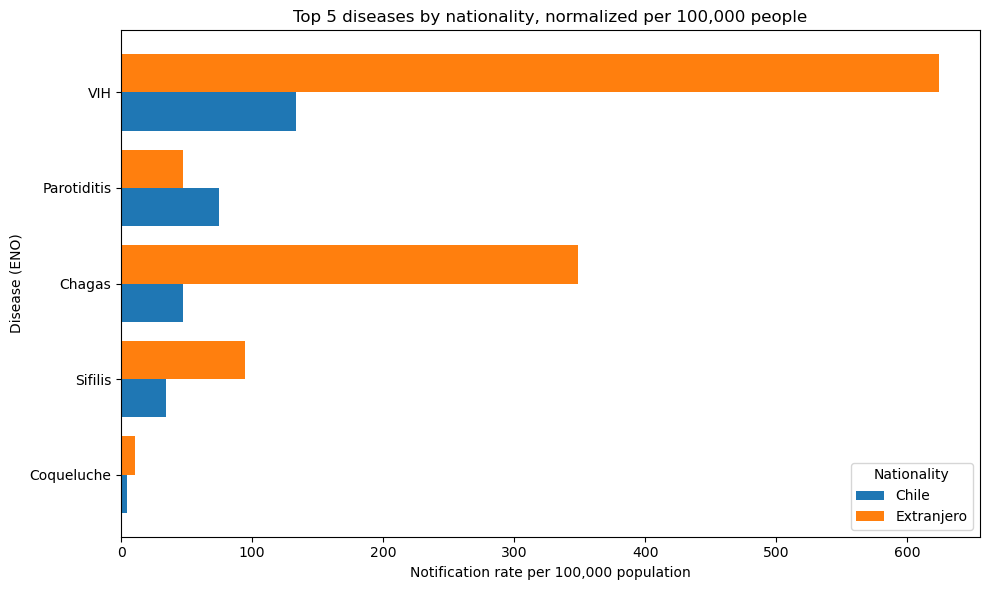

nacionalidad,ENO,Chile,Extranjero,total_notifications,Chile_share_pct,Foreign_share_pct,Chile_rate_100k,Foreign_rate_100k,Overrepresented_vs_local_population
0,VIH,460,238,698,65.90,34.10,133.29,624.25,True
1,Parotiditis,259,18,277,93.50,6.50,75.05,47.21,False
2,Chagas,164,133,297,55.22,44.78,47.52,348.84,True
3,Sifilis,119,36,155,76.77,23.23,34.48,94.42,True
4,Coqueluche,15,4,19,78.95,21.05,4.35,10.49,True


In [40]:
summary_table = pd.read_csv("../Datos/summary_table_part4.csv")

summary_selected = summary_table[
    summary_table["nombre_comuna"].isin(["Colina", "Melipilla", "Talagante"])
].copy()

total_pop_chilean = summary_selected["pop_chilean"].sum()
total_pop_foreign = summary_selected["pop_foreign"].sum()
pct_foreign = (total_pop_foreign / summary_selected["pop_total"].sum()) * 100

print(f"Total Chilean population: {int(total_pop_chilean):,}")
print(f"Total foreign population: {int(total_pop_foreign):,}")
print(f"Combined pct_foreign: {pct_foreign:.2f}%")

eno_com_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()
dropped_unknown_nat = (eno_com["nacionalidad"] == "Desconocido").sum()

print(f"Rows excluded because nacionalidad = 'Desconocido': {dropped_unknown_nat:,}")

top5_diseases = (
    eno_com["ENO"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

disease_nat_profile = (
    eno_com_nat[eno_com_nat["ENO"].isin(top5_diseases)]
    .groupby(["ENO", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Chile", "Extranjero"]:
    if col not in disease_nat_profile.columns:
        disease_nat_profile[col] = 0

disease_nat_profile = disease_nat_profile.reindex(top5_diseases)

disease_nat_profile["total_notifications"] = (
    disease_nat_profile["Chile"] + disease_nat_profile["Extranjero"]
)

disease_nat_profile["Chile_share_pct"] = (
    disease_nat_profile["Chile"] / disease_nat_profile["total_notifications"] * 100
).round(2)

disease_nat_profile["Foreign_share_pct"] = (
    disease_nat_profile["Extranjero"] / disease_nat_profile["total_notifications"] * 100
).round(2)

disease_nat_profile["Chile_rate_100k"] = (
    disease_nat_profile["Chile"] / total_pop_chilean * 100000
).round(2)

disease_nat_profile["Foreign_rate_100k"] = (
    disease_nat_profile["Extranjero"] / total_pop_foreign * 100000
).round(2)

disease_nat_profile["Overrepresented_vs_local_population"] = (
    disease_nat_profile["Foreign_share_pct"] > pct_foreign
)

disease_nat_profile = disease_nat_profile.reset_index()

int_cols = ["Chile", "Extranjero", "total_notifications"]
disease_nat_profile[int_cols] = disease_nat_profile[int_cols].astype(int)

plot_df = disease_nat_profile.set_index("ENO")[["Chile_rate_100k", "Foreign_rate_100k"]].copy()
plot_df.columns = ["Chile", "Extranjero"]
plot_df = plot_df.iloc[::-1]

ax = plot_df.plot(
    kind="barh",
    figsize=(10, 6),
    width=0.8
)

plt.title("Top 5 diseases by nationality, normalized per 100,000 people")
plt.xlabel("Notification rate per 100,000 population")
plt.ylabel("Disease (ENO)")
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

disease_nat_profile[[
    "ENO", "Chile", "Extranjero", "total_notifications",
    "Chile_share_pct", "Foreign_share_pct",
    "Chile_rate_100k", "Foreign_rate_100k",
    "Overrepresented_vs_local_population"
]]

Normalizes the top 5 disease counts by population size so Chilean and foreign rates can be compared fairly.


#### A. 2.3 Age-group distribution for the top disease


Most common disease in assigned comunas: VIH
Rows excluded because nacionalidad = 'Desconocido': 105
Rows excluded because grupo_edad = '***': 5


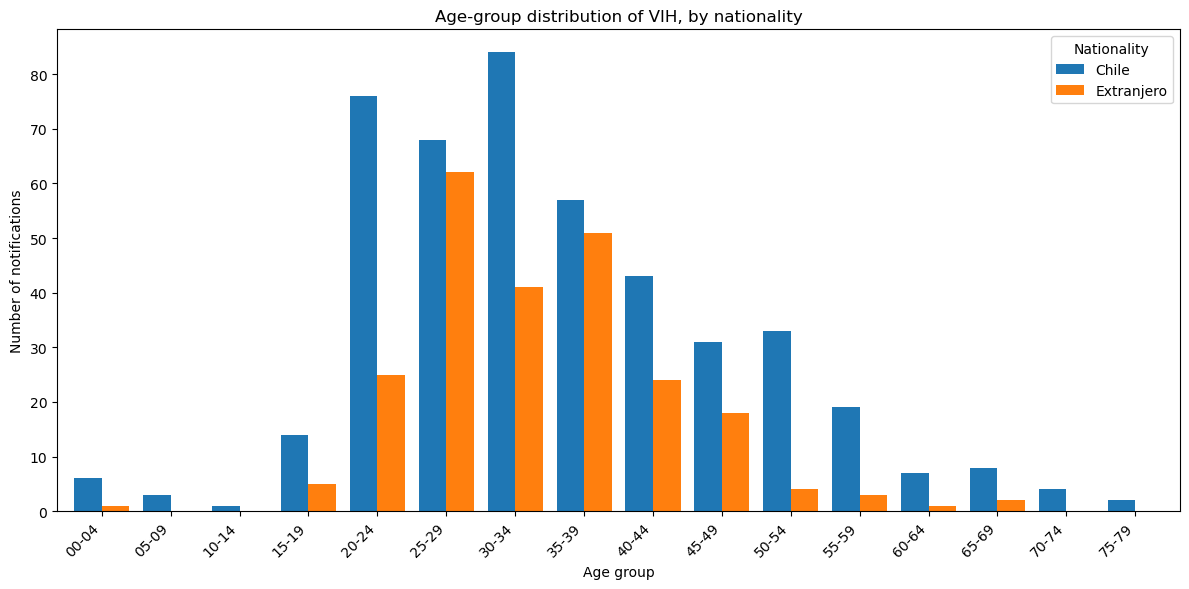

nacionalidad,grupo_edad,Chile,Extranjero
0,00-04,6,1
1,05-09,3,0
2,10-14,1,0
3,15-19,14,5
4,20-24,76,25
5,25-29,68,62
6,30-34,84,41
7,35-39,57,51
8,40-44,43,24
9,45-49,31,18


In [41]:
import re

top_disease = eno_com["ENO"].value_counts().idxmax()
print(f"Most common disease in assigned comunas: {top_disease}")

# 2) Keep only that disease, exclude unknown nationality, and remove *** age group
top_disease_df = eno_com[
    (eno_com["ENO"] == top_disease) &
    (eno_com["nacionalidad"] != "Desconocido") &
    (eno_com["grupo_edad"] != "***")
].copy()

dropped_unknown_nat = (
    (eno_com["ENO"] == top_disease) &
    (eno_com["nacionalidad"] == "Desconocido")
).sum()

dropped_unknown_age = (
    (eno_com["ENO"] == top_disease) &
    (eno_com["nacionalidad"] != "Desconocido") &
    (eno_com["grupo_edad"] == "***")
).sum()

print(f"Rows excluded because nacionalidad = 'Desconocido': {dropped_unknown_nat:,}")
print(f"Rows excluded because grupo_edad = '***': {dropped_unknown_age:,}")

# 3) Create a robust age-group order
def age_sort_key(x):
    s = str(x).strip().lower()
    
    if "menor" in s or "<1" in s:
        return -1
    if "descon" in s or "ign" in s or "sin info" in s:
        return 999
    
    match = re.search(r"\d+", s)
    if match:
        return int(match.group())
    
    return 998

age_order = sorted(
    top_disease_df["grupo_edad"].dropna().unique(),
    key=age_sort_key
)

# 4) Count notifications by age group and nationality
age_nat_profile = (
    top_disease_df.groupby(["grupo_edad", "nacionalidad"])
    .size()
    .reset_index(name="n_notifications")
)

age_nat_profile["grupo_edad"] = pd.Categorical(
    age_nat_profile["grupo_edad"],
    categories=age_order,
    ordered=True
)

age_nat_profile = age_nat_profile.sort_values("grupo_edad")

# 5) Reshape for plotting
age_nat_wide = (
    age_nat_profile.pivot(
        index="grupo_edad",
        columns="nacionalidad",
        values="n_notifications"
    )
    .fillna(0)
)

for col in ["Chile", "Extranjero"]:
    if col not in age_nat_wide.columns:
        age_nat_wide[col] = 0

age_nat_wide = age_nat_wide[["Chile", "Extranjero"]]

# Fix decimal display (remove .0)
age_nat_wide = age_nat_wide.astype(int)

# 6) Plot
ax = age_nat_wide.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title(f"Age-group distribution of {top_disease}, by nationality")
plt.xlabel("Age group")
plt.ylabel("Number of notifications")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

# 7) Show supporting table
age_nat_wide.reset_index()

Finds the most common disease, orders the age groups, and compares its distribution by nationality. As we can see, for Chileans, the age group with the most reports is 30-34 years, closely followed by the 20-24 age group. It should also be noted that for foreigners, the age group with the most reports is 25-29 years.

### A.3 Spatial View (0.5 pts)

#### A. 3.1 Notification counts by comuna 

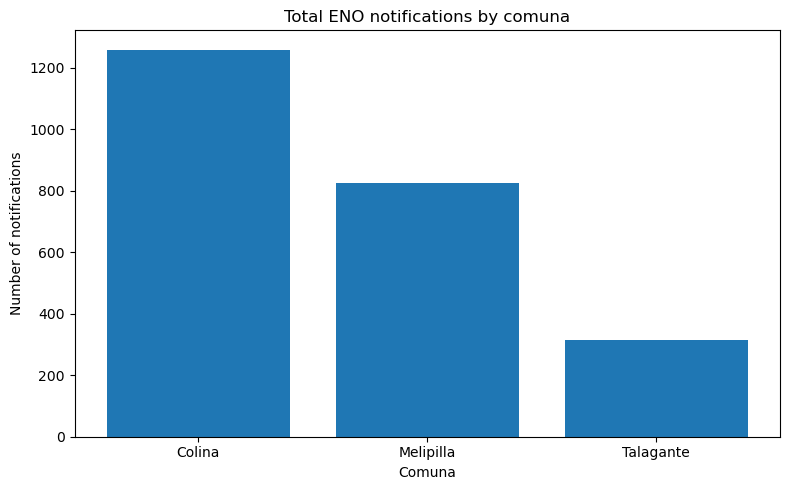

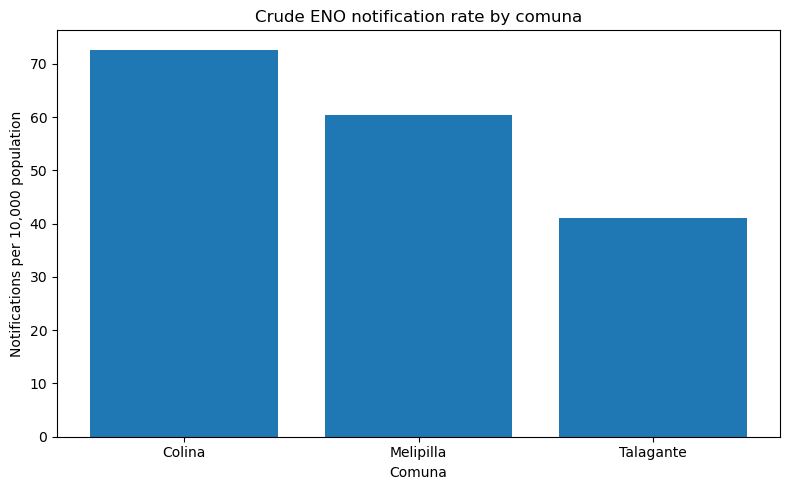

Rows with anonymized comuna code (*****): 148,217


,nombre_comuna,n_notifications,pop_total,crude_notification_rate_10k
0,Colina,1259,173293,72.65
1,Melipilla,824,136325,60.44
2,Talagante,314,76429,41.08


In [ ]:
ssummary_table = pd.read_csv("../Datos/summary_table_part4.csv")

# 2) Keep only the assigned comunas
summary_selected = summary_table[
    summary_table["nombre_comuna"].isin(["Colina", "Melipilla", "Talagante"])
].copy()

# Make comuna code compatible for merging
summary_selected["codigo_comuna"] = summary_selected["codigo_comuna"].astype(str)

# 3) Total ENO notifications per comuna (across all years)
counts_by_comuna = (
    eno_com.groupby("codigo_comuna_residencia")
    .size()
    .reset_index(name="n_notifications")
    .rename(columns={"codigo_comuna_residencia": "codigo_comuna"})
)

counts_by_comuna["codigo_comuna"] = counts_by_comuna["codigo_comuna"].astype(str)

# 4) Merge with comuna names and population from Tarea 1
comuna_summary = counts_by_comuna.merge(
    summary_selected[["codigo_comuna", "nombre_comuna", "pop_total"]],
    on="codigo_comuna",
    how="left"
)

# 5) Compute crude notification rate per 10,000 population
comuna_summary["crude_notification_rate_10k"] = (
    comuna_summary["n_notifications"] / comuna_summary["pop_total"] * 10000
).round(2)

# 6) Clean display types
comuna_summary["n_notifications"] = comuna_summary["n_notifications"].astype(int)
comuna_summary["pop_total"] = comuna_summary["pop_total"].astype(int)

# Keep a clean order
comuna_summary = comuna_summary.sort_values("n_notifications", ascending=False).reset_index(drop=True)

# 7) Bar chart: total notifications by comuna
plt.figure(figsize=(8, 5))
plt.bar(comuna_summary["nombre_comuna"], comuna_summary["n_notifications"])
plt.title("Total ENO notifications by comuna")
plt.xlabel("Comuna")
plt.ylabel("Number of notifications")
plt.tight_layout()
plt.show()

# 8) Bar chart: crude notification rate by comuna
plt.figure(figsize=(8, 5))
plt.bar(comuna_summary["nombre_comuna"], comuna_summary["crude_notification_rate_10k"])
plt.title("Crude ENO notification rate by comuna")
plt.xlabel("Comuna")
plt.ylabel("Notifications per 10,000 population")
plt.tight_layout()
plt.show()

# 9) Count anonymized comuna rows in the full ENO dataset
anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
print(f"Rows with anonymized comuna code (*****): {anon_count:,}")

# 10) Final summary table
comuna_summary[["nombre_comuna", "n_notifications", "pop_total", "crude_notification_rate_10k"]]

Counts ENO notifications by comuna, calculates simple rates, and shows both results with bar charts. The ENO figures by municipality don't reflect the full picture. Since there are over 148,000 records with the municipality hidden, it's impossible to know how many of those cases correspond to Colina, Melipilla, or Talagante. For this reason, the official numbers and rates we see end up being lower than what's actually happening.

### A.4 Comuna-Level ENO Summary Table (1 pt)


In [43]:
import os

summary_table = pd.read_csv("../Datos/summary_table_part4.csv")

summary_selected = summary_table[
    summary_table["nombre_comuna"].isin(["Colina", "Melipilla", "Talagante"])
].copy()

summary_selected["codigo_comuna"] = summary_selected["codigo_comuna"].astype(str)

def build_eno_summary(group):
    top3_diseases = (
        group["ENO"]
        .value_counts()
        .head(3)
        .index
        .tolist()
    )
    
    return pd.Series({
        "eno_total": len(group),
        "eno_chilean": (group["nacionalidad"] == "Chile").sum(),
        "eno_foreign": (group["nacionalidad"] == "Extranjero").sum(),
        "eno_desconocido": (group["nacionalidad"] == "Desconocido").sum(),
        "eno_top3_diseases": ", ".join(top3_diseases)
    })

# 3) Build ENO summary from the filtered ENO data
eno_summary = (
    eno_com.groupby("codigo_comuna_residencia")
    .apply(build_eno_summary)
    .reset_index()
    .rename(columns={"codigo_comuna_residencia": "codigo_comuna"})
)

eno_summary["codigo_comuna"] = eno_summary["codigo_comuna"].astype(str)

# 4) Merge comuna name and population from Tarea 1
eno_summary = summary_selected[["codigo_comuna", "nombre_comuna", "pop_total"]].merge(
    eno_summary,
    on="codigo_comuna",
    how="left"
)

# 5) Fill missing values if needed
count_cols = ["eno_total", "eno_chilean", "eno_foreign", "eno_desconocido"]
eno_summary[count_cols] = eno_summary[count_cols].fillna(0).astype(int)
eno_summary["eno_top3_diseases"] = eno_summary["eno_top3_diseases"].fillna("")

# 6) Compute crude notification rate per 10,000 population
eno_summary["eno_rate_per_10k"] = (
    eno_summary["eno_total"] / eno_summary["pop_total"] * 10000
).round(2)

# 7) Clean final display
eno_summary["codigo_comuna"] = eno_summary["codigo_comuna"].astype(int)
eno_summary["pop_total"] = eno_summary["pop_total"].astype(int)

eno_summary = eno_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "eno_total",
        "eno_chilean",
        "eno_foreign",
        "eno_desconocido",
        "eno_top3_diseases",
        "eno_rate_per_10k"
    ]
].sort_values("codigo_comuna").reset_index(drop=True)

# 8) Save as CSV
eno_summary.to_csv("../Datos/tarea2_eno_summary.csv", index=False)

# 9) Display final table
eno_summary

,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13301,Colina,1259,576,174,509,"Parotiditis, VIH, Sifilis",72.65
1,13501,Melipilla,824,387,245,192,"VIH, Chagas, Parotiditis",60.44
2,13601,Talagante,314,186,32,96,"VIH, Parotiditis, Chagas",41.08


Creates a comuna-level ENO summary table and saves it as a CSV file for later use.


## Part B: GRD -- Hospital Discharges (5 pts)

### B.0 Data Loading & Cleaning (1.5 pts)

#### B.0.1 Load GRD files for 2022--2024

In [44]:
import zipfile

grd_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

encodings = {2022: "utf-16", 2023: "utf-16", 2024: "latin-1"}

frames = []

for year in [2022, 2023, 2024]:
    zippath = f"../Datos/GRD_PUBLICO_{year}.zip"

    with zipfile.ZipFile(zippath) as z:
        txtname = [name for name in z.namelist() if name.lower().endswith(".txt")][0]
        print(f"{year} -> reading: {txtname} ({encodings[year]})")

        with z.open(txtname) as f:
            df_year = pd.read_csv(
                f,
                sep="|",
                encoding=encodings[year],
                usecols=grd_cols,
                low_memory=False
            )

    df_year["year"] = year
    frames.append(df_year)

grd = pd.concat(frames, ignore_index=True)

print(f"Total discharges in 2022-2024: {len(grd):,}")
print(grd.shape)
grd.info()
grd.head()

2022 -> reading: GRD_PUBLICO_EXTERNO_2022.txt (utf-16)
2023 -> reading: GRD_PUBLICO_2023.txt (utf-16)
2024 -> reading: GRD_PUBLICO_2024.txt (latin-1)
Total discharges in 2022-2024: 3,058,240
(3058240, 15)
<class 'pandas.DataFrame'>
RangeIndex: 3058240 entries, 0 to 3058239
Data columns (total 15 columns):
 #   Column               Dtype
---  ------               -----
 0   SEXO                 str  
 1   FECHA_NACIMIENTO     str  
 2   COMUNA               str  
 3   NACIONALIDAD         str  
 4   TIPO_INGRESO         str  
 5   ESPECIALIDAD_MEDICA  str  
 6   FECHA_INGRESO        str  
 7   FECHAALTA            str  
 8   TIPOALTA             str  
 9   DIAGNOSTICO1         str  
 10  DIAGNOSTICO2         str  
 11  IR_29301_COD_GRD     str  
 12  IR_29301_SEVERIDAD   str  
 13  IR_29301_MORTALIDAD  str  
 14  year                 int64
dtypes: int64(1), str(14)
memory usage: 662.2 MB


,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,IR_29301_COD_GRD,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year
0,HOMBRE,2022-01-02,SAN FERNANDO,CHILE,URGENCIA,PEDIATRÃA,2022-08-01,2022-08-09,DOMICILIO,Q03.9,H55,011113,3,1,2022
1,MUJER,1981-07-05,COPIAPO,CHILE,PROGRAMADA,CARDIOLOGÃA,2022-11-01,2022-11-04,DOMICILIO,I47.1,I10,051401,1,1,2022
2,MUJER,1941-06-30,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-30,2022-07-06,FALLECIDO,S72.00,W19.09,084103,3,3,2022
3,MUJER,1997-01-26,MELIPILLA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÃA,2022-07-04,2022-07-07,DOMICILIO,O80.0,Z37.0,146131,1,1,2022
4,MUJER,1950-06-03,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-01,2022-07-04,DOMICILIO,J40,B96.2,044213,3,2,2022


Loads the GRD files for 2022 to 2024, combines them, and shows a quick check of the merged dataset.


#### B.0.2 Filter to your comunas

In [45]:
# --------------------------------------------------
# B.0.2 Filter to your comunas
# --------------------------------------------------

my_comuna_names = ["COLINA", "MELIPILLA", "TALAGANTE"]

# Filter GRD to assigned comunas
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()

# Total discharges in assigned comunas
print(f"Discharges in my comunas {len(grd_com):,}")

# Discharges by comuna
print("\nDischarges by comuna")
print(grd_com["COMUNA"].value_counts())

# Discharges by year
discharges_per_year = (
    grd_com.groupby("year")
    .size()
    .reset_index(name="n_discharges")
    .sort_values("year")
    .reset_index(drop=True)
)

print("\nDischarges by year in my comunas")
print(discharges_per_year)

# Optional table by comuna and year
discharges_comuna_year = (
    grd_com.groupby(["COMUNA", "year"])
    .size()
    .reset_index(name="n_discharges")
    .sort_values(["COMUNA", "year"])
    .reset_index(drop=True)
)

print("\nDischarges by comuna and year")
print(discharges_comuna_year)

Discharges in my comunas 56,488

Discharges by comuna
COMUNA
MELIPILLA    29404
COLINA       14742
TALAGANTE    12342
Name: count, dtype: int64

Discharges by year in my comunas
   year  n_discharges
0  2022         17031
1  2023         19202
2  2024         20255

Discharges by comuna and year
      COMUNA  year  n_discharges
0     COLINA  2022          4730
1     COLINA  2023          5064
2     COLINA  2024          4948
3  MELIPILLA  2022          8611
4  MELIPILLA  2023          9812
5  MELIPILLA  2024         10981
6  TALAGANTE  2022          3690
7  TALAGANTE  2023          4326
8  TALAGANTE  2024          4326


Filters hospital discharges to the three assigned comunas and summarizes them by comuna and year.


#### B.0.3 Compute length of stay

In [46]:
# --------------------------------------------------
# B.0.3 Compute length of stay
# --------------------------------------------------

# 0) Keep the original number of rows before filtering
total_rows_before = len(grd_com)

# 1) Convert dates
grd_com["fecha_ingreso_dt"] = pd.to_datetime(
    grd_com["FECHA_INGRESO"],
    errors="coerce"
)

grd_com["fecha_alta_dt"] = pd.to_datetime(
    grd_com["FECHAALTA"],
    errors="coerce"
)

# 2) Compute length of stay in days
grd_com["los"] = (
    grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]
).dt.days

# 3) Report problematic rows
missing_los_count = grd_com["los"].isna().sum()
negative_los_count = (grd_com["los"] < 0).sum()

pct_missing_los = round(missing_los_count / total_rows_before * 100, 2)
pct_negative_los = round(negative_los_count / total_rows_before * 100, 2)

print(f"Total rows before LOS filtering: {total_rows_before:,}")
print(f"Rows with missing los because of invalid dates: {missing_los_count:,} ({pct_missing_los}%)")
print(f"Rows with los < 0 removed: {negative_los_count:,} ({pct_negative_los}%)")

# 4) Keep only valid stays
grd_com_los = grd_com[grd_com["los"].notna() & (grd_com["los"] >= 0)].copy()

# 5) Report kept rows and percentage retained
rows_kept = len(grd_com_los)
pct_kept = round(rows_kept / total_rows_before * 100, 2)

print(f"Rows kept after filtering valid los: {rows_kept:,} ({pct_kept}%)")

# 6) Report distribution of length of stay
los_summary = pd.DataFrame({
    "statistic": ["mean", "median", "min", "max"],
    "value": [
        round(grd_com_los["los"].mean(), 2),
        round(grd_com_los["los"].median(), 2),
        int(grd_com_los["los"].min()),
        int(grd_com_los["los"].max())
    ]
})

los_summary

Total rows before LOS filtering: 56,488
Rows with missing los because of invalid dates: 19,203 (33.99%)
Rows with los < 0 removed: 0 (0.0%)
Rows kept after filtering valid los: 37,285 (66.01%)


,statistic,value
0,mean,5.53
1,median,2.00
2,min,0.00
3,max,594.00


Calculates length of stay, removes invalid cases, and summarizes the valid stays that remain.


#### B.0.4 Create a nationality grouping

In [47]:
grd_com["nat_group"] = (
    grd_com["NACIONALIDAD"]
    .fillna("")
    .str.strip()
    .str.upper()
    .apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")
)

# Report distribution
nat_group_dist = (
    grd_com["nat_group"]
    .value_counts()
    .reset_index()
)

nat_group_dist.columns = ["nat_group", "n_discharges"]
nat_group_dist["pct"] = (
    nat_group_dist["n_discharges"] / len(grd_com) * 100
).round(2)

print(f"Total discharges in filtered GRD data {len(grd_com):,}")
nat_group_dist

Total discharges in filtered GRD data 56,488


,nat_group,n_discharges,pct
0,Chilean,51333,90.87
1,Foreign,5155,9.13


Creates a simple nationality group in the GRD data and shows its distribution.


#### B.0.5 Join diagnoses to CIE-10

In [48]:
cie10 = pd.read_excel(
    "../Datos/CIE-10.xlsx",
    sheet_name="CIE 10"
)

print(cie10.columns.tolist())
cie10.head()

['VersiÃ³n', 'CÃ³digo', 'DescripciÃ³n', 'CategorÃ­a', 'SecciÃ³n', 'CapÃ­tulo']


,VersiÃ³n,CÃ³digo,DescripciÃ³n,CategorÃ­a,SecciÃ³n,CapÃ­tulo
0,CIE-v2013,A00,CÃ³lera,A00 CÃ“LERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
1,CIE-v2013,A00.0,"CÃ³lera debido a Vibrio cholerae O1, biotipo ch...",A00 CÃ“LERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
2,CIE-v2013,A00.1,"CÃ³lera debido a Vibrio cholerae O1, biotipo El...",A00 CÃ“LERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
3,CIE-v2013,A00.9,"CÃ³lera, no especificado",A00 CÃ“LERA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...
4,CIE-v2013,A01,Fiebres tifoidea y paratifoidea,A01 FIEBRES TIFOIDEA Y PARATIFOIDEA,A00-A09 ENFERMEDADES INFECCIOSAS INTESTINALES,Cap.01 CIERTAS ENFERMEDADES INFECCIOSAS Y PAR...


Loads the CIE-10 lookup table and previews the columns that will be used for the match.


In [49]:
# --------------------------------------------------
# B.0.5 Join diagnoses to CIE-10
# --------------------------------------------------

# 1) Load CIE-10 lookup table
cie10 = pd.read_excel(
    "../Datos/CIE-10.xlsx",
    sheet_name="CIE 10"
)

# 2) Keep only needed columns and clean join keys
cie10 = cie10[["CÃ³digo", "DescripciÃ³n", "CapÃ­tulo"]].copy()
cie10["CÃ³digo"] = cie10["CÃ³digo"].astype(str).str.strip().str.upper()

# 3) Work on a clean copy of grd_com
grd_com_cie = grd_com.copy()

# Remove old merge columns if they already exist
cols_to_drop = ["CÃ³digo", "DescripciÃ³n", "CapÃ­tulo"]
grd_com_cie = grd_com_cie.drop(
    columns=[c for c in cols_to_drop if c in grd_com_cie.columns],
    errors="ignore"
)

# Clean diagnosis code
grd_com_cie["DIAGNOSTICO1"] = (
    grd_com_cie["DIAGNOSTICO1"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# 4) Join DIAGNOSTICO1 to CIE-10
grd_com_cie = grd_com_cie.merge(
    cie10.drop_duplicates(subset="CÃ³digo"),
    left_on="DIAGNOSTICO1",
    right_on="CÃ³digo",
    how="left"
)

# 5) Report failed matches
failed_matches = grd_com_cie["CapÃ­tulo"].isna().sum()
failed_matches_pct = round(failed_matches / len(grd_com_cie) * 100, 2)

print(f"Rows that failed to match CIE-10 {failed_matches:,} ({failed_matches_pct}%)")

# 6) Quick check
grd_com_cie[["DIAGNOSTICO1", "CÃ³digo", "DescripciÃ³n", "CapÃ­tulo"]].head()

Rows that failed to match CIE-10 3 (0.01%)


,DIAGNOSTICO1,CÃ³digo,DescripciÃ³n,CapÃ­tulo
0,S72.00,S72.00,"Fractura del cuello de fÃ©mur, cerrada","Cap.19 LESIONES TRAUMÃTICAS, ENVENENAMIENTOS ..."
1,O80.0,O80.0,"Parto Ãºnico espontÃ¡neo, presentaciÃ³n cefÃ¡lica ...","Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)"
2,J40,J40,"Bronquitis, no especificada como aguda o crÃ³nica",Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...
3,U07.1,U07.1,"COVID-19, virus identificado",Cap.22 CÃ“DIGOS PARA SITUACIONES ESPECIALES (U...
4,J18.9,J18.9,"NeumonÃ­a, no especificada",Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...


Cleans the diagnosis codes, joins them with CIE-10 labels, and checks how many rows did not match.


### B.1 Diagnostic Profile (1.5 pts)

#### B.1.1 Top diagnostic chapters

Rows excluded because CapÃ­tulo is missing: 3


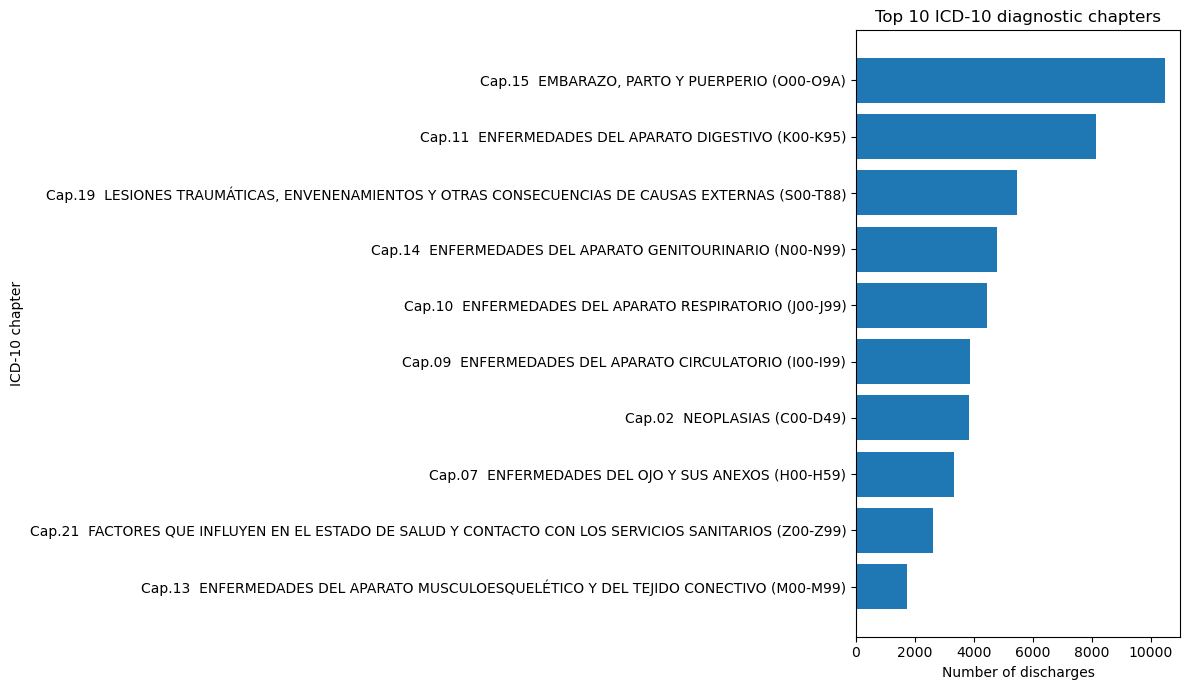

,CapÃ­tulo,n_discharges
0,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",10465
1,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,8140
2,"Cap.19 LESIONES TRAUMÃTICAS, ENVENENAMIENTOS ...",5469
3,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,4794
4,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,4458
5,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,3861
6,Cap.02 NEOPLASIAS (C00-D49),3819
7,Cap.07 ENFERMEDADES DEL OJO Y SUS ANEXOS (H00...,3317
8,Cap.21 FACTORES QUE INFLUYEN EN EL ESTADO DE ...,2623
9,Cap.13 ENFERMEDADES DEL APARATO MUSCULOESQUEL...,1715


In [50]:
grd_chapters = grd_com_cie[grd_com_cie["CapÃ­tulo"].notna()].copy()

unmatched_chapters = grd_com_cie["CapÃ­tulo"].isna().sum()
print(f"Rows excluded because CapÃ­tulo is missing: {unmatched_chapters:,}")

top10_chapters = (
    grd_chapters["CapÃ­tulo"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))
plt.barh(top10_chapters.index, top10_chapters.values)

plt.title("Top 10 ICD-10 diagnostic chapters")
plt.xlabel("Number of discharges")
plt.ylabel("ICD-10 chapter")
plt.tight_layout()
plt.show()

top10_chapters_table = (
    grd_chapters["CapÃ­tulo"]
    .value_counts()
    .head(10)
    .reset_index()
)

top10_chapters_table.columns = ["CapÃ­tulo", "n_discharges"]
top10_chapters_table

Shows the most common diagnostic chapters and plots the top 10. ALso the top diagnostic chapters give us a general view of the main health problems behind hospital discharges in Colina, Melipilla and Talagante. Since only 3 cases did not match the CIE-10 table, this summary is quite reliable. Overall, the most frequent chapters show which broad disease groups are most common in these comunas.


#### B.1.2 Top specific diagnoses

Rows excluded because DescripciÃ³n is missing 3


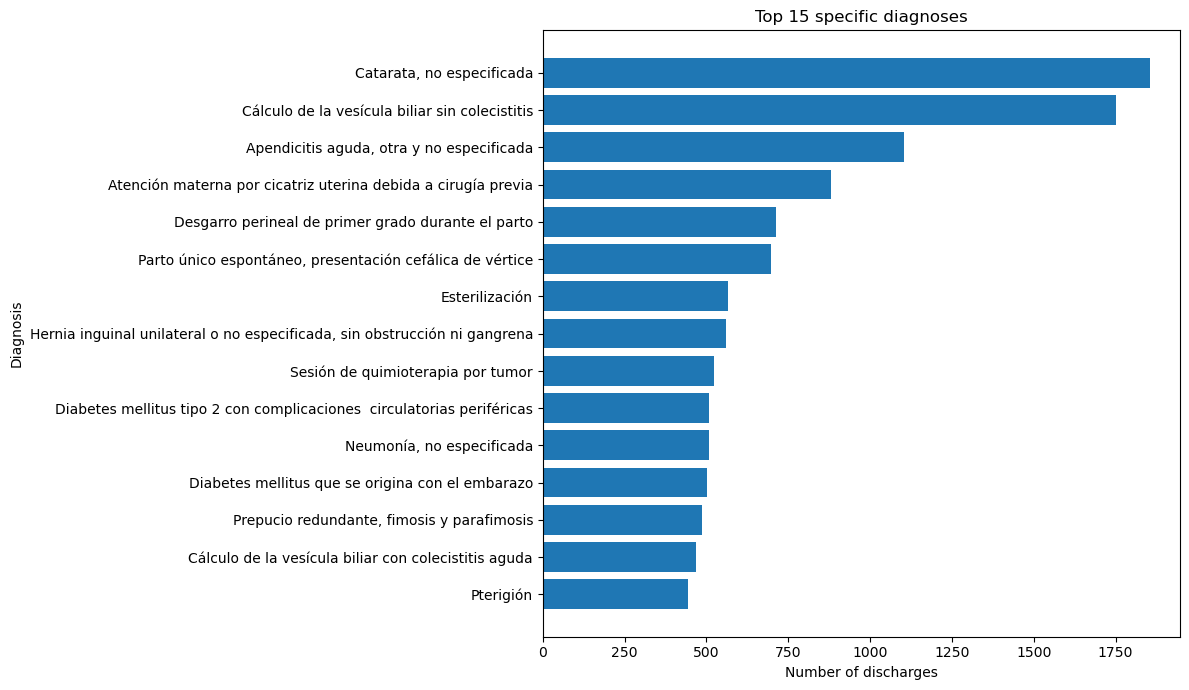

,DescripciÃ³n,n_discharges
0,"Catarata, no especificada",1854
1,CÃ¡lculo de la vesÃ­cula biliar sin colecistitis,1752
2,"Apendicitis aguda, otra y no especificada",1102
3,AtenciÃ³n materna por cicatriz uterina debida a...,879
4,Desgarro perineal de primer grado durante el p...,711
5,"Parto Ãºnico espontÃ¡neo, presentaciÃ³n cefÃ¡lica ...",696
6,EsterilizaciÃ³n,565
7,"Hernia inguinal unilateral o no especificada, ...",561
8,SesiÃ³n de quimioterapia por tumor,522
9,Diabetes mellitus tipo 2 con complicaciones c...,509


In [52]:
grd_diag = grd_com_cie[grd_com_cie["DescripciÃ³n"].notna()].copy()

unmatched_desc = grd_com_cie["DescripciÃ³n"].isna().sum()
print(f"Rows excluded because DescripciÃ³n is missing {unmatched_desc:,}")

top15_diag = (
    grd_diag["DescripciÃ³n"]
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))
plt.barh(top15_diag.index, top15_diag.values)

plt.title("Top 15 specific diagnoses")
plt.xlabel("Number of discharges")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()

top15_diag_table = (
    grd_diag["DescripciÃ³n"]
    .value_counts()
    .head(15)
    .reset_index()
)

top15_diag_table.columns = ["DescripciÃ³n", "n_discharges"]
top15_diag_table

Shows the most common specific diagnoses and plots the top 15.


#### B.1.3 Diagnostic chapters by nationality

Reference pct_foreign from Tarea 1 9.88%


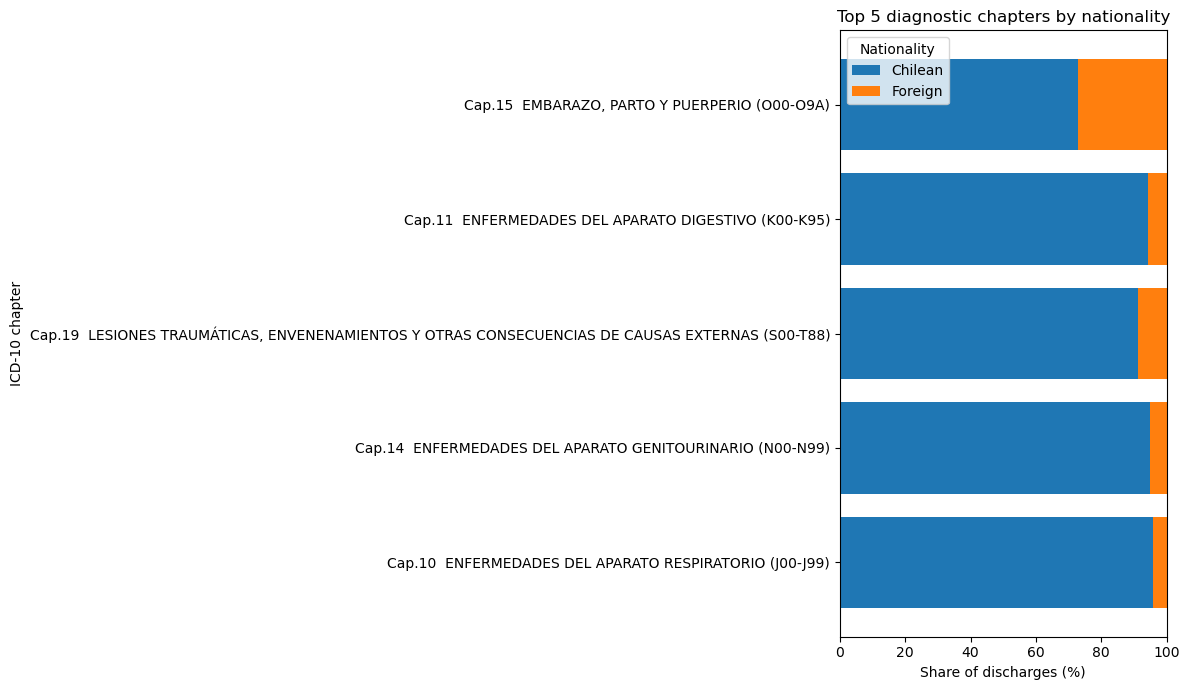

nat_group,CapÃ­tulo,Chilean,Foreign,total_discharges,Chilean_share_pct,Foreign_share_pct,Overrepresented_vs_local_population
0,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",7609,2856,10465,72.71,27.29,True
1,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,7666,474,8140,94.18,5.82,False
2,"Cap.19 LESIONES TRAUMÃTICAS, ENVENENAMIENTOS ...",4992,477,5469,91.28,8.72,False
3,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,4552,242,4794,94.95,5.05,False
4,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,4272,186,4458,95.83,4.17,False


In [53]:
grd_chapters = grd_com_cie[grd_com_cie["CapÃ­tulo"].notna()].copy()

try:
    pct_foreign
except NameError:
    summary_table = pd.read_csv("../Datos/summary_table_part4.csv")
    summary_selected = summary_table[
        summary_table["nombre_comuna"].isin(["Colina", "Melipilla", "Talagante"])
    ].copy()
    
    pct_foreign = (
        summary_selected["pop_foreign"].sum() / summary_selected["pop_total"].sum()
    ) * 100

print(f"Reference pct_foreign from Tarea 1 {pct_foreign:.2f}%")

top5_chapters = (
    grd_chapters["CapÃ­tulo"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

chapter_nat = (
    grd_chapters[grd_chapters["CapÃ­tulo"].isin(top5_chapters)]
    .groupby(["CapÃ­tulo", "nat_group"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Chilean", "Foreign"]:
    if col not in chapter_nat.columns:
        chapter_nat[col] = 0

chapter_nat = chapter_nat.reindex(top5_chapters)

chapter_nat["total_discharges"] = chapter_nat["Chilean"] + chapter_nat["Foreign"]

chapter_nat["Chilean_share_pct"] = (
    chapter_nat["Chilean"] / chapter_nat["total_discharges"] * 100
).round(2)

chapter_nat["Foreign_share_pct"] = (
    chapter_nat["Foreign"] / chapter_nat["total_discharges"] * 100
).round(2)

chapter_nat["Overrepresented_vs_local_population"] = (
    chapter_nat["Foreign_share_pct"] > pct_foreign
)

chapter_nat = chapter_nat.reset_index()

int_cols = ["Chilean", "Foreign", "total_discharges"]
chapter_nat[int_cols] = chapter_nat[int_cols].astype(int)

plot_df = chapter_nat.set_index("CapÃ­tulo")[["Chilean_share_pct", "Foreign_share_pct"]]
plot_df.columns = ["Chilean", "Foreign"]
plot_df = plot_df.iloc[::-1]

ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    width=0.8
)

plt.title("Top 5 diagnostic chapters by nationality")
plt.xlabel("Share of discharges (%)")
plt.ylabel("ICD-10 chapter")
plt.xlim(0, 100)
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

chapter_nat[[
    "CapÃ­tulo", "Chilean", "Foreign", "total_discharges",
    "Chilean_share_pct", "Foreign_share_pct",
    "Overrepresented_vs_local_population"
]]

Compares the top diagnostic chapters by nationality and highlights where foreign patients appear more often than expected. Among the top 5 diagnostic chapters, only Chapter XV pregnancy, childbirth and the puerperium shows a clear over-representation of foreign patients. Its foreign share reaches 27.29%, which is much higher than the local pct_foreign of 9.88%. In contrast, the other main chapters remain below that reference, so their discharge profiles are mostly concentrated among Chilean patients.

### B.2 Length of Stay & Severity (1 pt)

#### B.2.1 Length of stay by nationality

Mean and median length of stay by nationality


,nat_group,mean_los,median_los
0,Chilean,5.65,2.0
1,Foreign,4.35,2.0


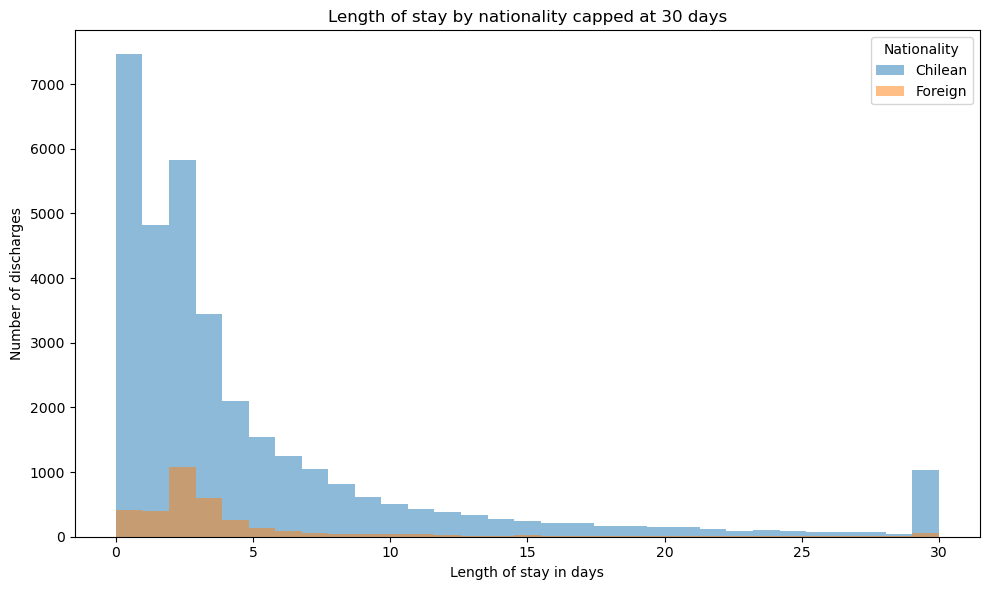

<Figure size 800x500 with 0 Axes>

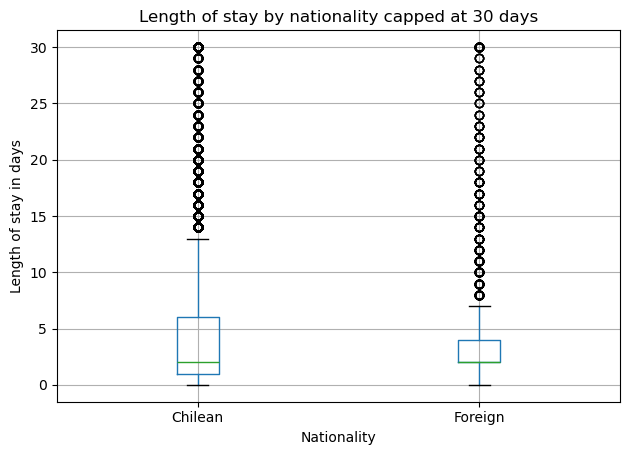

In [59]:
grd_los_nat = grd_com_los.copy()

grd_los_nat["nat_group"] = (
    grd_los_nat["NACIONALIDAD"]
    .fillna("")
    .str.strip()
    .str.upper()
    .apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")
)

los_nat_summary = (
    grd_los_nat.groupby("nat_group")["los"]
    .agg(mean_los="mean", median_los="median")
    .reset_index()
)

los_nat_summary["mean_los"] = los_nat_summary["mean_los"].round(2)
los_nat_summary["median_los"] = los_nat_summary["median_los"].round(2)

print("Mean and median length of stay by nationality")
display(los_nat_summary)

grd_los_nat["los_capped_30"] = grd_los_nat["los"].clip(upper=30)

plt.figure(figsize=(10, 6))

for group in ["Chilean", "Foreign"]:
    subset = grd_los_nat.loc[grd_los_nat["nat_group"] == group, "los_capped_30"]
    plt.hist(
        subset,
        bins=31,
        alpha=0.5,
        label=group
    )

plt.title("Length of stay by nationality capped at 30 days")
plt.xlabel("Length of stay in days")
plt.ylabel("Number of discharges")
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
grd_los_nat.boxplot(column="los_capped_30", by="nat_group")

plt.title("Length of stay by nationality capped at 30 days")
plt.suptitle("")
plt.xlabel("Nationality")
plt.ylabel("Length of stay in days")
plt.tight_layout()
plt.show()

Compares length of stay by nationality using summary numbers, a histogram, and a boxplot. Length of stay is broadly similar in both groups in terms of the typical case, since the median is 2 days for both Chilean and foreign patients. However, the mean is higher among Chilean patients, 5.65 versus 4.35 days, which suggests more long hospital stays in that group. Overall, the difference exists, but it seems to come mainly from the upper tail rather than from a large shift in the whole distribution. This is also visible in the histogram, where both groups are concentrated in short stays, but the Chilean group shows a longer right tail.

#### B.2.2 Severity distribution

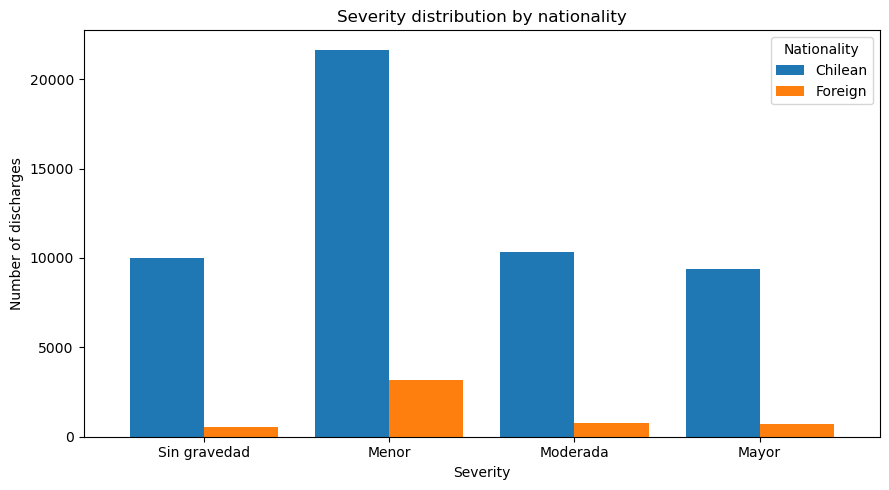

nat_group,IR_29301_SEVERIDAD,severity_label,Chilean,Foreign
0,0,Sin gravedad,9982,517
1,1,Menor,21647,3182
2,2,Moderada,10347,772
3,3,Mayor,9356,684


In [61]:
import unicodedata

def normalize_name(x):
    x = str(x).strip().lower()
    x = ''.join(
        c for c in unicodedata.normalize("NFKD", x)
        if not unicodedata.combining(c)
    )
    return x.replace(" ", "_")

sev_lookup = pd.read_excel(
    "../Datos/TablasMaestrasBasesGRD.xlsx",
    sheet_name="Severidad GRD"
)

original_cols = sev_lookup.columns.tolist()
sev_lookup.columns = [normalize_name(c) for c in sev_lookup.columns]

code_col = None
label_col = None

for c in ["ir_29301_severidad", "codigo", "cod", "severidad"]:
    if c in sev_lookup.columns:
        code_col = c
        break

for c in ["descripcion", "glosa", "nombre", "etiqueta", "detalle"]:
    if c in sev_lookup.columns:
        label_col = c
        break

if code_col is None:
    code_col = sev_lookup.columns[0]

if label_col is None:
    label_col = sev_lookup.columns[1]

sev_lookup = sev_lookup[[code_col, label_col]].copy()
sev_lookup.columns = ["severity_code", "severity_label"]

sev_lookup["severity_code"] = pd.to_numeric(
    sev_lookup["severity_code"],
    errors="coerce"
).astype("Int64")

sev_lookup["severity_label"] = sev_lookup["severity_label"].astype(str).str.strip()

sev_lookup = sev_lookup.dropna(subset=["severity_code"]).drop_duplicates(subset=["severity_code"])

grd_sev = grd_com.copy()

if "nat_group" not in grd_sev.columns:
    grd_sev["nat_group"] = (
        grd_sev["NACIONALIDAD"]
        .fillna("")
        .str.strip()
        .str.upper()
        .apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")
    )

grd_sev["IR_29301_SEVERIDAD"] = pd.to_numeric(
    grd_sev["IR_29301_SEVERIDAD"],
    errors="coerce"
).astype("Int64")

grd_sev = grd_sev[grd_sev["IR_29301_SEVERIDAD"].isin([0, 1, 2, 3])].copy()

grd_sev = grd_sev.merge(
    sev_lookup,
    left_on="IR_29301_SEVERIDAD",
    right_on="severity_code",
    how="left"
)

fallback_labels = {
    0: "0 No severity",
    1: "1 Minor",
    2: "2 Moderate",
    3: "3 Major"
}

grd_sev["severity_label"] = grd_sev.apply(
    lambda row: fallback_labels.get(row["IR_29301_SEVERIDAD"], "Unknown")
    if pd.isna(row["severity_label"]) else row["severity_label"],
    axis=1
)

sev_nat = (
    grd_sev.groupby(["IR_29301_SEVERIDAD", "severity_label", "nat_group"])
    .size()
    .reset_index(name="n_discharges")
)

sev_nat_wide = (
    sev_nat.pivot_table(
        index=["IR_29301_SEVERIDAD", "severity_label"],
        columns="nat_group",
        values="n_discharges",
        fill_value=0
    )
    .reset_index()
    .sort_values("IR_29301_SEVERIDAD")
)

for col in ["Chilean", "Foreign"]:
    if col not in sev_nat_wide.columns:
        sev_nat_wide[col] = 0

plot_df = sev_nat_wide.set_index("severity_label")[["Chilean", "Foreign"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.8
)

plt.title("Severity distribution by nationality")
plt.xlabel("Severity")
plt.ylabel("Number of discharges")
plt.xticks(rotation=0)
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

sev_nat_wide.assign(
    Chilean=sev_nat_wide["Chilean"].astype(int),
    Foreign=sev_nat_wide["Foreign"].astype(int)
)[["IR_29301_SEVERIDAD", "severity_label", "Chilean", "Foreign"]]

Links severity codes to readable labels and compares severity levels by nationality.


#### B.2.3 Discharge type

In [62]:
grd_alta = grd_com.copy()

if "nat_group" not in grd_alta.columns:
    grd_alta["nat_group"] = (
        grd_alta["NACIONALIDAD"]
        .fillna("")
        .str.strip()
        .str.upper()
        .apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")
    )

grd_alta["TIPOALTA_clean"] = (
    grd_alta["TIPOALTA"]
    .fillna("")
    .str.strip()
    .str.upper()
)

discharge_dist = (
    grd_alta.groupby(["TIPOALTA_clean", "nat_group"])
    .size()
    .reset_index(name="n_discharges")
)

discharge_dist_wide = (
    discharge_dist.pivot(
        index="TIPOALTA_clean",
        columns="nat_group",
        values="n_discharges"
    )
    .fillna(0)
    .reset_index()
)

for col in ["Chilean", "Foreign"]:
    if col not in discharge_dist_wide.columns:
        discharge_dist_wide[col] = 0

discharge_dist_wide["Chilean"] = discharge_dist_wide["Chilean"].astype(int)
discharge_dist_wide["Foreign"] = discharge_dist_wide["Foreign"].astype(int)
discharge_dist_wide["total_discharges"] = (
    discharge_dist_wide["Chilean"] + discharge_dist_wide["Foreign"]
)

discharge_dist_wide = discharge_dist_wide.sort_values(
    "total_discharges", ascending=False
).reset_index(drop=True)

print("Distribution of discharge outcomes by nationality")
display(discharge_dist_wide[["TIPOALTA_clean", "Chilean", "Foreign", "total_discharges"]])

mortality_table = (
    grd_alta.assign(is_dead=grd_alta["TIPOALTA_clean"] == "FALLECIDO")
    .groupby("nat_group")
    .agg(
        total_discharges=("TIPOALTA_clean", "size"),
        fallecido_discharges=("is_dead", "sum")
    )
    .reset_index()
)

mortality_table["in_hospital_mortality_rate_pct"] = (
    mortality_table["fallecido_discharges"] / mortality_table["total_discharges"] * 100
).round(2)

mortality_table["total_discharges"] = mortality_table["total_discharges"].astype(int)
mortality_table["fallecido_discharges"] = mortality_table["fallecido_discharges"].astype(int)

print("In-hospital mortality rate by nationality")
mortality_table

Distribution of discharge outcomes by nationality


nat_group,TIPOALTA_clean,Chilean,Foreign,total_discharges
0,DOMICILIO,47181,4902,52083
1,FALLECIDO,1238,39,1277
2,DERIVACIÃ“N OTRO HOSPITAL DEL SERVICIO,909,91,1000
3,HOSPITALIZACIÃ“N DOMICILIARIA,769,23,792
4,ALTA VOLUNTARIA,542,48,590
5,DERIVACIÃ“N OTRO HOSPITAL DE LA RED NACIONAL,254,17,271
6,"DERIVACIÃ“N A OTROS CENTROS (CÃRCEL, HOGAR DE",182,9,191
7,FUGA DEL PACIENTE,119,16,135
8,DERIVACIÃ“N INST. PRIVADA (COMPRA DE SERVICIOS,111,8,119
9,DERIVACIÃ“N INST. PRIVADA (VOLUNTARIO),28,2,30


In-hospital mortality rate by nationality


,nat_group,total_discharges,fallecido_discharges,in_hospital_mortality_rate_pct
0,Chilean,51333,1238,2.41
1,Foreign,5155,39,0.76


Summarizes discharge outcomes by nationality and calculates the in-hospital mortality rate.


### B.3 Spatial View (0.5 pts)

#### B.3.1 Choropleth: hospitalization rate by comuna

#### B.4 Comuna-Level GRD Summary Table (0.5 pts)

Hospitalization rate table


,codigo_comuna,nombre_comuna,n_discharges,pop_total,hosp_rate_per_10k
0,13301,Colina,14742,173293,850.70
1,13501,Melipilla,29404,136325,2156.90
2,13601,Talagante,12342,76429,1614.83


Columns in shapefile
['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry']
Detected code column cod_comuna
Detected name column None


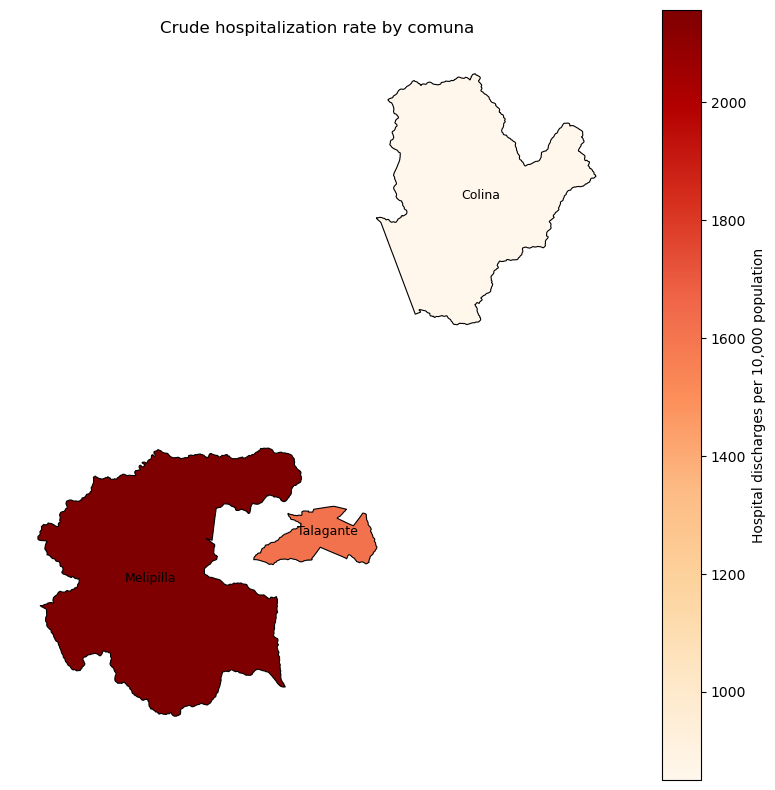

In [64]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --------------------------------------------------
# B.3.1 Choropleth - hospitalization rate by comuna
# --------------------------------------------------

summary_table = pd.read_csv("../Datos/summary_table_part4.csv")

summary_selected = summary_table[
    summary_table["nombre_comuna"].isin(["Colina", "Melipilla", "Talagante"])
].copy()

summary_selected["codigo_comuna"] = summary_selected["codigo_comuna"].astype(str)
summary_selected["nombre_comuna_upper"] = summary_selected["nombre_comuna"].str.upper().str.strip()

grd_counts = (
    grd_com.groupby("COMUNA")
    .size()
    .reset_index(name="n_discharges")
)

grd_counts["COMUNA"] = grd_counts["COMUNA"].str.upper().str.strip()

hosp_rates = summary_selected.merge(
    grd_counts,
    left_on="nombre_comuna_upper",
    right_on="COMUNA",
    how="left"
)

hosp_rates["n_discharges"] = hosp_rates["n_discharges"].fillna(0).astype(int)

hosp_rates["hosp_rate_per_10k"] = (
    hosp_rates["n_discharges"] / hosp_rates["pop_total"] * 10000
).round(2)

print("Hospitalization rate table")
display(hosp_rates[["codigo_comuna", "nombre_comuna", "n_discharges", "pop_total", "hosp_rate_per_10k"]])

comunas_gdf = gpd.read_file("../Datos/comunas.shp")

print("Columns in shapefile")
print(comunas_gdf.columns.tolist())

code_candidates = [
    "CUT_COM", "COD_COMUNA", "CODIGO_COM", "codigo_comuna", "CUT", "cut_com",
    "cod_comuna", "codcom", "COMUNA"
]

name_candidates = [
    "NOM_COM", "NOM_COMUNA", "NOMBRE_COM", "NOMBRE_COMUNA", "nombre_comuna",
    "nom_comuna", "nom_com", "comuna", "COMUNA"
]

shape_code_col = next((c for c in code_candidates if c in comunas_gdf.columns), None)
shape_name_col = next((c for c in name_candidates if c in comunas_gdf.columns), None)

print("Detected code column", shape_code_col)
print("Detected name column", shape_name_col)

if shape_code_col is not None:
    comunas_gdf[shape_code_col] = comunas_gdf[shape_code_col].astype(str)
    map_gdf = comunas_gdf.merge(
        hosp_rates[["codigo_comuna", "nombre_comuna", "hosp_rate_per_10k"]],
        left_on=shape_code_col,
        right_on="codigo_comuna",
        how="inner"
    )
elif shape_name_col is not None:
    comunas_gdf["shape_name_upper"] = comunas_gdf[shape_name_col].astype(str).str.upper().str.strip()
    map_gdf = comunas_gdf.merge(
        hosp_rates[["nombre_comuna", "hosp_rate_per_10k", "nombre_comuna_upper"]],
        left_on="shape_name_upper",
        right_on="nombre_comuna_upper",
        how="inner"
    )
else:
    raise ValueError("No se encontrÃ³ una columna reconocible de cÃ³digo o nombre de comuna en el shapefile")

fig, ax = plt.subplots(figsize=(8, 8))

map_gdf.plot(
    column="hosp_rate_per_10k",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Hospital discharges per 10,000 population"}
)

for _, row in map_gdf.iterrows():
    if row.geometry is not None and not row.geometry.is_empty:
        point = row.geometry.representative_point()
        ax.text(
            point.x,
            point.y,
            row["nombre_comuna"],
            fontsize=9,
            ha="center"
        )

ax.set_title("Crude hospitalization rate by comuna")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Combines discharge counts with population and map data to show hospitalization rates by comuna.


### B.4 Comuna-Level GRD Summary Table (0.5 pts)

In [66]:
summary_table = pd.read_csv("../Datos/summary_table_part4.csv")

summary_selected = summary_table[
    summary_table["nombre_comuna"].isin(["Colina", "Melipilla", "Talagante"])
].copy()

summary_selected["codigo_comuna"] = summary_selected["codigo_comuna"].astype(int)
summary_selected["pop_total"] = summary_selected["pop_total"].astype(int)
summary_selected["COMUNA"] = summary_selected["nombre_comuna"].str.upper().str.strip()

grd_base = grd_com.copy()
grd_base["COMUNA"] = grd_base["COMUNA"].astype(str).str.upper().str.strip()

grd_base["nat_group"] = (
    grd_base["NACIONALIDAD"]
    .fillna("")
    .str.strip()
    .str.upper()
    .apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")
)

grd_base["TIPOALTA_clean"] = (
    grd_base["TIPOALTA"]
    .fillna("")
    .str.strip()
    .str.upper()
)

grd_base["IR_29301_SEVERIDAD_num"] = pd.to_numeric(
    grd_base["IR_29301_SEVERIDAD"],
    errors="coerce"
)

grd_base.loc[
    ~grd_base["IR_29301_SEVERIDAD_num"].isin([0, 1, 2, 3]),
    "IR_29301_SEVERIDAD_num"
] = pd.NA

grd_total = (
    grd_base.groupby("COMUNA")
    .size()
    .reset_index(name="grd_total")
)

grd_chilean = (
    grd_base[grd_base["nat_group"] == "Chilean"]
    .groupby("COMUNA")
    .size()
    .reset_index(name="grd_chilean")
)

grd_foreign = (
    grd_base[grd_base["nat_group"] == "Foreign"]
    .groupby("COMUNA")
    .size()
    .reset_index(name="grd_foreign")
)

grd_los = grd_com.copy()
grd_los["COMUNA"] = grd_los["COMUNA"].astype(str).str.upper().str.strip()

grd_los["fecha_ingreso_dt"] = pd.to_datetime(
    grd_los["FECHA_INGRESO"],
    errors="coerce"
)

grd_los["fecha_alta_dt"] = pd.to_datetime(
    grd_los["FECHAALTA"],
    errors="coerce"
)

grd_los["los"] = (
    grd_los["fecha_alta_dt"] - grd_los["fecha_ingreso_dt"]
).dt.days

grd_los = grd_los[grd_los["los"].notna() & (grd_los["los"] >= 0)].copy()

grd_los["nat_group"] = (
    grd_los["NACIONALIDAD"]
    .fillna("")
    .str.strip()
    .str.upper()
    .apply(lambda x: "Chilean" if x == "CHILE" else "Foreign")
)

grd_mean_los = (
    grd_los.groupby("COMUNA")["los"]
    .mean()
    .reset_index(name="grd_mean_los")
)

grd_mean_los_chilean = (
    grd_los[grd_los["nat_group"] == "Chilean"]
    .groupby("COMUNA")["los"]
    .mean()
    .reset_index(name="grd_mean_los_chilean")
)

grd_mean_los_foreign = (
    grd_los[grd_los["nat_group"] == "Foreign"]
    .groupby("COMUNA")["los"]
    .mean()
    .reset_index(name="grd_mean_los_foreign")
)

grd_mean_severity = (
    grd_base.groupby("COMUNA")["IR_29301_SEVERIDAD_num"]
    .mean()
    .reset_index(name="grd_mean_severity")
)

grd_mortality = (
    grd_base.assign(is_dead=grd_base["TIPOALTA_clean"] == "FALLECIDO")
    .groupby("COMUNA")["is_dead"]
    .mean()
    .reset_index(name="grd_mortality_rate")
)

grd_mortality["grd_mortality_rate"] = grd_mortality["grd_mortality_rate"] * 100

chapters_valid = grd_com_cie[grd_com_cie["CapÃ­tulo"].notna()].copy()
chapters_valid["COMUNA"] = chapters_valid["COMUNA"].astype(str).str.upper().str.strip()

grd_top3_chapters = (
    chapters_valid.groupby("COMUNA")["CapÃ­tulo"]
    .apply(lambda x: ", ".join(x.value_counts().head(3).index.tolist()))
    .reset_index(name="grd_top3_chapters")
)

# 8) Merge all summaries
grd_summary = summary_selected[["codigo_comuna", "nombre_comuna", "pop_total", "COMUNA"]].copy()

for df in [
    grd_total,
    grd_chilean,
    grd_foreign,
    grd_mean_los,
    grd_mean_los_chilean,
    grd_mean_los_foreign,
    grd_mean_severity,
    grd_mortality,
    grd_top3_chapters
]:
    grd_summary = grd_summary.merge(df, on="COMUNA", how="left")

count_cols = ["grd_total", "grd_chilean", "grd_foreign"]
grd_summary[count_cols] = grd_summary[count_cols].fillna(0).astype(int)

grd_summary["grd_pct_foreign"] = (
    grd_summary["grd_foreign"] / grd_summary["grd_total"] * 100
).round(2)

grd_summary["grd_rate_per_10k"] = (
    grd_summary["grd_total"] / grd_summary["pop_total"] * 10000
).round(2)

grd_summary["grd_top3_chapters"] = grd_summary["grd_top3_chapters"].fillna("")

round_cols = [
    "grd_mean_los",
    "grd_mean_los_chilean",
    "grd_mean_los_foreign",
    "grd_mean_severity",
    "grd_mortality_rate"
]

grd_summary[round_cols] = grd_summary[round_cols].round(2)

grd_summary = grd_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "grd_total",
        "grd_chilean",
        "grd_foreign",
        "grd_pct_foreign",
        "grd_mean_los",
        "grd_mean_los_chilean",
        "grd_mean_los_foreign",
        "grd_mean_severity",
        "grd_mortality_rate",
        "grd_top3_chapters",
        "grd_rate_per_10k"
    ]
].sort_values("codigo_comuna").reset_index(drop=True)

os.makedirs("tarea2_grd_summary.csv", exist_ok=True)
grd_summary.to_csv("../Datos/tarea2_grd_summary.csv", index=False)

print("Saved file output/tarea2_grd_summary.csv")
grd_summary

Saved file output/tarea2_grd_summary.csv


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13301,Colina,14742,12697,2045,13.87,5.88,6.06,4.72,1.41,2.04,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",850.70
1,13501,Melipilla,29404,26882,2522,8.58,4.98,5.09,3.89,1.23,2.23,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",2156.90
2,13601,Talagante,12342,11754,588,4.76,6.46,6.53,5.09,1.63,2.60,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1614.83


Builds the final GRD summary table by comuna and saves it as a CSV file.
